### **MCPI Calculator**

0. We compute the MCPI using the formula: 
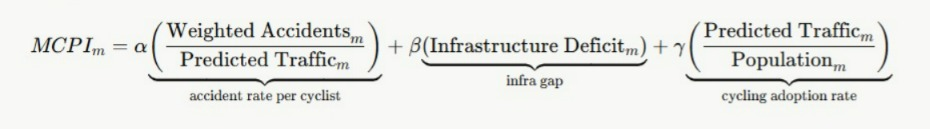

1. Aggregate the Raw Hourly Bike Counts to a "yearly" count, for 2026 use the predicted bike counts
2. Compute the first term by matching the Bike-Count Municipality to the Accident Score Municipality
3. Compute the Third Term by simply dividing yearly bike count by population
4. Use sklearn's `MinMaxScaler()` to standardize each term, give the parameters equal weights
5. Compute yearly **MCPI**, for each municipality

In [28]:
import pandas as pd
import numpy as np

In [29]:
df_sites = pd.read_csv("C:/Users/Horia/Desktop/KUL/Modern Data Analytics/complete_sites.csv")
df_accidents = pd.read_csv("C:/Users/Horia/Desktop/KUL/Modern Data Analytics/accidents_scores.csv")
df_model = pd.read_csv("C:/Users/Horia/Desktop/KUL/Modern Data Analytics/model_df_pred.csv")

**Step 1:** Aggregating the bike-counts per municipality, per year

In [30]:
# Join to get municipality name
df_model = df_model.merge(
    df_sites[['counter_id', 'municipality']],
    on='counter_id',
    how='left'
)

# Aggregate: yearly bike count per municipality
yearly_counts = (
    df_model.groupby(['municipality', 'year'])
    .agg(yearly_bike_count=('bike_count', 'sum'))
    .reset_index()
)

Adding the `Population` and `Infrastructure_Deficit` per Municipality, per year

In [31]:
sites_dedup = df_sites[['municipality', 'infrastructure_deficit', 'population']].drop_duplicates(subset='municipality')

yearly_counts = yearly_counts.merge(sites_dedup, on='municipality', how='left')

**Step 2:** Adding the Accidents Score

If Municipality names do not match, we use the `accident_score` from the arrondissement

In [33]:
# Step 1: add arrondissement to yearly_counts
muni_arr = df_sites[['municipality', 'arrondissement']].drop_duplicates(subset='municipality')
yearly_counts = yearly_counts.merge(muni_arr, on='municipality', how='left')

# Step 2: compute arrondissement-level accident score
# map accident municipalities to arrondissements using complete_sites as bridge
acc_with_arr = df_accidents.merge(muni_arr, on='municipality', how='left')

arr_acc = (
    acc_with_arr.groupby(['arrondissement', 'year'])
    ['accident_score'].mean()
    .reset_index()
    .rename(columns={'accident_score': 'accident_score_arr'})
)

# Step 3: direct match on municipality + year
yearly_counts = yearly_counts.merge(
    df_accidents[['municipality', 'year', 'accident_score']],
    on=['municipality', 'year'],
    how='left'
)

# Step 4: for unmatched rows, fill from arrondissement-level average
yearly_counts = yearly_counts.merge(arr_acc, on=['arrondissement', 'year'], how='left')

yearly_counts['accident_score'] = yearly_counts['accident_score'].fillna(
    yearly_counts['accident_score_arr']
)

yearly_counts = yearly_counts.drop(columns='accident_score_arr')


In [35]:
yearly_counts.to_csv('yearly_pred.csv', index=False)

**Step 3:** After manually correcting some entries, we have the final dataset to compute the MCPI

Starting with equal weights for each term, which can later be adjusted in the interactive dashboard

In [36]:
mcpi_df = pd.read_csv("C:/Users/Horia/Desktop/KUL/Modern Data Analytics/mcpi_check.csv")

In [37]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Step 1: compute raw terms
mcpi_df['term1'] = mcpi_df['accident_score'] / mcpi_df['yearly_bike_count']
mcpi_df['term2'] = mcpi_df['infrastructure_deficit']
mcpi_df['term3'] = mcpi_df['yearly_bike_count'] / mcpi_df['population']

# Step 2: replace infinities and NaNs
mcpi_df['term1'] = mcpi_df['term1'].replace([np.inf, -np.inf], np.nan)
mcpi_df['term3'] = mcpi_df['term3'].replace([np.inf, -np.inf], np.nan)
mcpi_df[['term1', 'term2', 'term3']] = mcpi_df[['term1', 'term2', 'term3']].fillna(0)

# Step 3: scale each term to [0, 1]
scaler = MinMaxScaler()
mcpi_df[['term1_scaled', 'term2_scaled', 'term3_scaled']] = scaler.fit_transform(
    mcpi_df[['term1', 'term2', 'term3']]
)

# Step 4: compute MCPI with equal weights
a = b = c = 1/3
mcpi_df['MCPI'] = (
    a * mcpi_df['term1_scaled'] +
    b * mcpi_df['term2_scaled'] +
    c * mcpi_df['term3_scaled']
).round(4)

**Step 4:** Plotting the MCPI across Flanders with `Plotly`

In [40]:
import plotly.express as px

# Get one coordinate per municipality (average if multiple counters)
coords = (
    df_sites.groupby('municipality')
    .agg(lat=('lat', 'mean'), lon=('lon', 'mean'))
    .reset_index()
)

# Pick the year you want to visualise
plot_df = mcpi_df[mcpi_df['year'] == 2026].merge(coords, on='municipality', how='left')

fig = px.scatter_mapbox(
    plot_df,
    lat='lat',
    lon='lon',
    color='MCPI',
    size='MCPI',
    hover_name='municipality',
    color_continuous_scale='RdYlGn_r',  # red = high MCPI, green = low
    zoom=6.8,
    center={'lat': 51.0, 'lon': 4.5},
    mapbox_style='carto-positron',
    title='MCPI per Municipality in Flanders (2026)'
)
fig.update_layout(
    hoverlabel=dict(
        font_size=16
    )
)

fig.show()


If we want to compare to the "observed" entries for 2026 map, just change `mcpi_check.csv` to `mcpi_init.csv`